In [1]:
import numpy as np 
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import statsmodels.formula.api as smf
from scipy.optimize import nnls
from scipy.linalg import null_space
from OffManifoldLearning.factor_analysis import est_dim_crossval, est_intrinsic_manifold

# Load and prepare data

In [2]:
rng = np.random.default_rng(0)
path = 'data/efc1_all.tsv'
chords = pd.read_csv(os.path.join(path), sep='\t',)
chords = chords[chords.trialCorr==1].reset_index()
chords.MD = pd.to_numeric(chords.MD, errors='coerce')
chords.ET = pd.to_numeric(chords.ET, errors='coerce')
chords['log_MD'] = -np.log(chords.MD)

Nf = 5
single_finger = chords[chords.num_fingers==1].copy().reset_index(drop=True)
multi_finger = chords[chords.num_fingers>1].copy().reset_index(drop=True)

col_f = [f'diff_force_f{i + 1}' for i in range(Nf)]

sns = chords.sn.unique()

N = len(sns)

n_perms = 100
n_targets = 100
theta_target = rng.uniform(0, 2 * np.pi, n_targets)
radius = 4.3
pos_target = radius * np.column_stack([np.cos(theta_target), np.sin(theta_target)])

In [3]:
def eucl_from_subspace(F, Q):
    """
    F : (15, N) matrix of N vectors
    Q : (15, k) orthonormal basis for the manifold W
    Returns the Euclidean distance of each column of F from W, shape (N,).
    """
    F_parallel = Q @ (Q.T @ F)
    F_perp = F - F_parallel
    return np.linalg.norm(F_perp, axis=0)

def angle_from_subspace(F, Q):
    """
    F : (15, N) matrix of N vectors
    Q : (15, k) orthonormal basis for the manifold W
    Returns the angle (in radians) between each column of F and the subspace W, shape (N,).
    """
    F_parallel = Q @ (Q.T @ F)
    F_perp = F - F_parallel
    
    norm_parallel = np.linalg.norm(F_parallel, axis=0)
    norm_perp = np.linalg.norm(F_perp, axis=0)
    
    theta = np.arctan2(norm_perp, norm_parallel)
    return theta  # radians; multiply by 180/np.pi for degrees

def make_D_on(A, Q, G):
    D_on = A @ G @ Q.T                      # (2, 15)
    return D_on

def make_D_off(A, Q, G):
    D_off = A @ Q.T @ G                       # (2, 15)
    return D_off

In [ ]:
eucl, angle, magnitude = ([] for _ in range(3))
sim = pd.DataFrame(columns=['sn', 'manifold', 'magnitude', 'theta_pos', 'dist', 'theta'])
for s, sn in enumerate(sns):

    # single finger
    F_sf = single_finger[single_finger.sn == sn][col_f].to_numpy().astype(float)
    sf_mean = F_sf.mean(axis=0, keepdims=True)
    sf_std = F_sf.std(axis=0, keepdims=True)
    F_sf_z = (F_sf - sf_mean) / sf_std # z-score

    # estimate intrinsic manifold with FA
    k, *_ = est_dim_crossval(F_sf_z, k_range=range(1, 5), n_folds=4)
    print(f"estimated intrinsic dimensionality for subj {sn}: {k}")
    L, _ = est_intrinsic_manifold(F_sf_z, k=k)

    # multi finger
    F_ch = multi_finger[multi_finger.sn == sn][col_f].to_numpy().astype(float)
    F_ch_z = (F_ch - sf_mean) / sf_std 

    # calc euclidean and angle to manifold for each multi-finger trial
    Q, _ = np.linalg.qr(L) # orthonormalize the loading matrix, each column is a basis vector for the manifold
    eucl.extend(eucl_from_subspace(F_ch_z.T, Q))
    angle.extend(np.log(np.tan(angle_from_subspace(F_ch_z.T, Q))))
    magnitude.extend(np.linalg.norm(F_ch, axis=1))

    M = rng.normal(size=(k, 2))
    A, _ = np.linalg.qr(M)
    A = A.T  # shape (2, k)

    # run simulations
    if k > 1:
        for n in range(n_perms):

            # on manifold
            p_on = rng.permutation(k)
            G_on = np.eye(k)[p_on]
            D_on = make_D_on(A, Q, G_on)
            F_on = pos_target @ D_on
            eucl_on = eucl_from_subspace(F_on.T, Q)
            mag_on = np.linalg.norm(F_on, axis=1)
            angle_on = angle_from_subspace(F_on.T, Q  )
            sim = pd.concat([sim, pd.DataFrame({
            'sn': sn,
            'manifold': 'on',
            'magnitude': mag_on,
            'theta_pos': theta_target,
            'dist':     eucl_on,
            'theta':    angle_on,})])

            # off manifold
            p_off = rng.permutation(Nf)
            G_off = np.eye(Nf)[p_off]
            D_off = make_D_off(A, Q, G_off)
            F_off = pos_target @ D_off
            eucl_off = eucl_from_subspace(F_off.T, Q)
            mag_off = np.linalg.norm(F_off, axis=1)
            angle_off = angle_from_subspace(F_off.T, Q)
            sim = pd.concat([sim, pd.DataFrame({
            'sn': sn,
            'manifold': 'off',
            'magnitude': mag_off,
            'theta_pos': theta_target,
            'dist':     eucl_off,
            'theta':    angle_off,})])

multi_finger['magnitude'] = magnitude
multi_finger['euclidean'] = eucl
multi_finger['angle'] = angle


estimated intrinsic dimensionality for subj 1: 3


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 4429 is different from 5)

In [5]:
md_align = smf.mixedlm("MD ~ euclidean", multi_finger, groups=multi_finger['sn']).fit()
md_align.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
=========================================================
Model:            MixedLM Dependent Variable: MD         
No. Observations: 62634   Method:             REML       
No. Groups:       14      Scale:              0.5595     
Min. group size:  4377    Log-Likelihood:     -70732.8093
Max. group size:  4635    Converged:          Yes        
Mean group size:  4473.9                                 
----------------------------------------------------------
            Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept   0.861     0.051  16.987  0.000   0.761   0.960
euclidean   0.097     0.003  33.135  0.000   0.091   0.102
Group Var   0.035     0.019                               
=========================================================

"""

In [6]:
md_align = smf.mixedlm("MD ~ angle", multi_finger, groups=multi_finger['sn']).fit()
md_align.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
=========================================================
Model:            MixedLM Dependent Variable: MD         
No. Observations: 62634   Method:             REML       
No. Groups:       14      Scale:              0.5693     
Min. group size:  4377    Log-Likelihood:     -71276.0997
Max. group size:  4635    Converged:          Yes        
Mean group size:  4473.9                                 
----------------------------------------------------------
           Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept   1.065     0.052  20.496  0.000   0.963   1.167
angle      -0.004     0.003  -1.431  0.152  -0.009   0.001
Group Var   0.038     0.020                               
=========================================================

"""

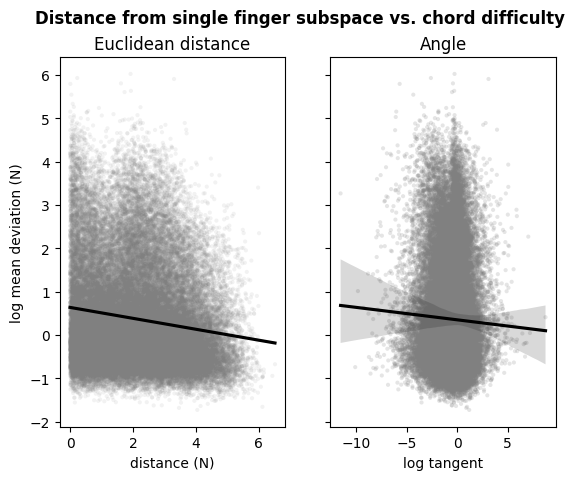

In [7]:
fig, axs = plt.subplots(1, 2, sharey=True)

ax = axs[0]
sb.scatterplot(data=multi_finger, ax=ax, x='euclidean', y='log_MD', alpha=.1, color='grey', edgecolor='none', marker='.')
sb.regplot(data=multi_finger, ax=ax, x='euclidean', y='log_MD', scatter=False, color='black')
ax.set_title('Euclidean distance')
ax.set_xlabel('distance (N)')
ax.set_ylabel('log mean deviation (N)')

ax = axs[1]
sb.scatterplot(data=multi_finger, ax=ax, x='angle', y='log_MD', alpha=.2, color='grey', edgecolor='none',marker='.')
sb.regplot(data=multi_finger, ax=ax, x='angle', y='log_MD', scatter=False, color='black', units='sn')
ax.set_title('Angle')
ax.set_xlabel('log tangent')

fig.suptitle('Distance from single finger subspace vs. chord difficulty', fontweight='bold')

plt.show()

# Radial targets
To simulate what would really happen in the rehabilitation task during off-manifold rehabilitation, I defined the radially arranged targets below and estimated the multi-finger force patterns required by the on- and off-manifold decoders ($
\mathbf{D}_{\text{on}}$ and $
\mathbf{D}_{\text{off}}$) to reach them. 

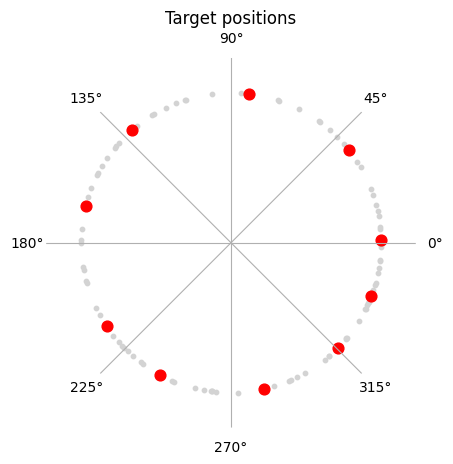

In [8]:
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

n_show = 10
idx = np.argsort(theta_target)[::n_targets // n_show][:n_show]

ax.scatter(theta_target, np.full(n_targets, radius), s=10, color='lightgrey',)
ax.scatter(theta_target[idx], np.full(n_show, radius), s=60, color='red',)
ax.set_ylim(0, radius + 1)
ax.set_rticks([])
#ax.set_xticks([])
ax.spines['polar'].set_visible(False)
ax.set_title('Target positions')
plt.show()

# Example force patterns
The figure below shows some example force patterns required by $\mathbf{D_{on}}$ and $\mathbf{D_{off}}$ to reach the radial targets showed in red in the figure above.

ValueError: operands could not be broadcast together with shapes (5,) (0,) 

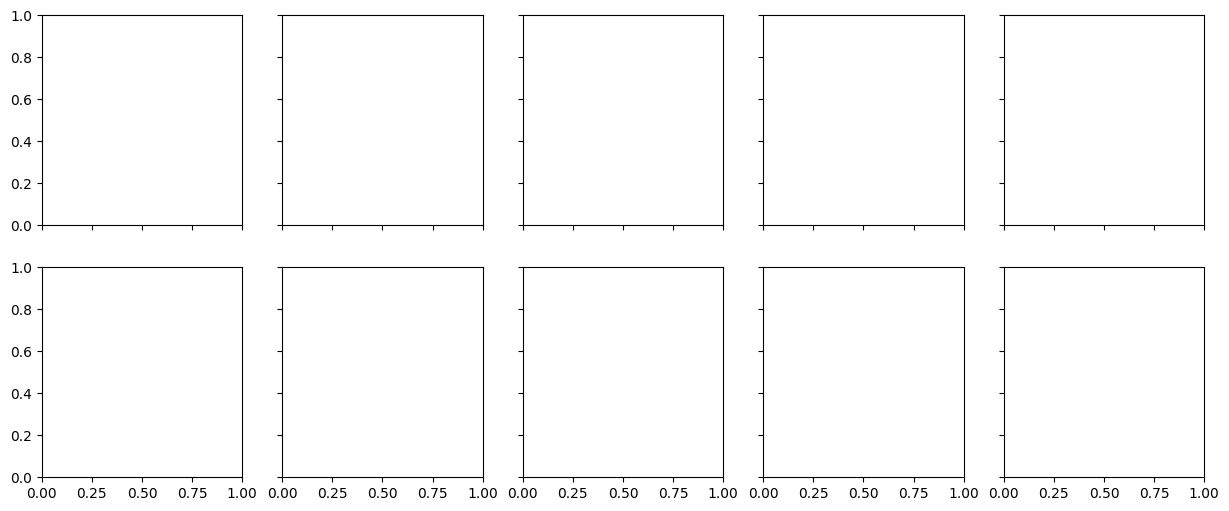

In [9]:
sel_on, sel_off = F_on[idx], F_off[idx]
x      = np.arange(Nf)
labels = ['thumb', 'index', 'middle', 'ring', 'pinkie']
rmax   = max(np.abs(sel_on).max(), np.abs(sel_off).max())

fig, axs = plt.subplots(2, 5, figsize=(15, 6), sharey=True, sharex=True)
for i, ax in enumerate(axs.ravel()):
    ax.plot(x, sel_on[i, :5] - sel_on[i, 5:],  'o-', color='C0', label='on')
    ax.plot(x, sel_off[i, :5] - sel_off[i, 5:], 'o-', color='C3', label='off')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels,)
    ax.set_title(f'target θ = {np.degrees(theta_target[idx[i]]):.0f}°', fontsize=9)

fig.supylabel('flexion - extension force (N)')
axs[0, -1].legend(loc='upper right', fontsize=8)
fig.suptitle(r'Example force patterns for $D_{on}$ and $D_{off}$', fontweight='bold')
plt.tight_layout()
plt.show()

# Magnitude of the simulated force patterns
By adjusting the target radius, I matched the average magnitude of the force patterns required by the two decoders to reach the radial targets with that of the real multi-finger force patterns for chords.

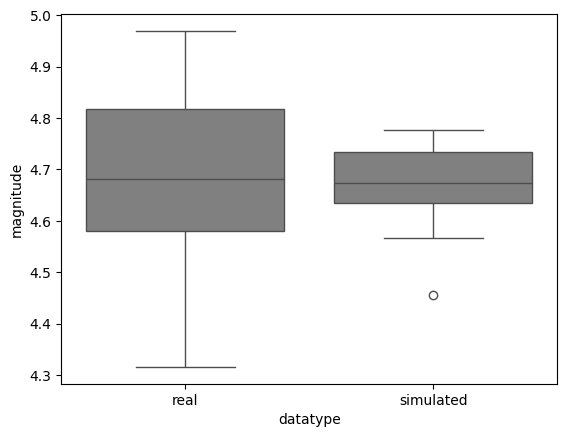

In [ ]:
multi_finger['datatype'] = 'real'
sim['datatype'] = 'simulated'
df = pd.concat([multi_finger[['sn', 'magnitude', 'datatype']], sim[['sn', 'magnitude', 'datatype']]])
df_g = df.groupby(['sn', 'datatype']).mean(numeric_only=True).reset_index()

sb.boxplot(data=df_g, x='datatype', y='magnitude',color='grey',)

plt.show()

# Distance of simulated force patterns from the intrinsic force manifold
The Euclidean distance and angle relative to the intrinsic force manifold reflected whether the decoder used to simulate the force patterns operates on- or off-manifold.

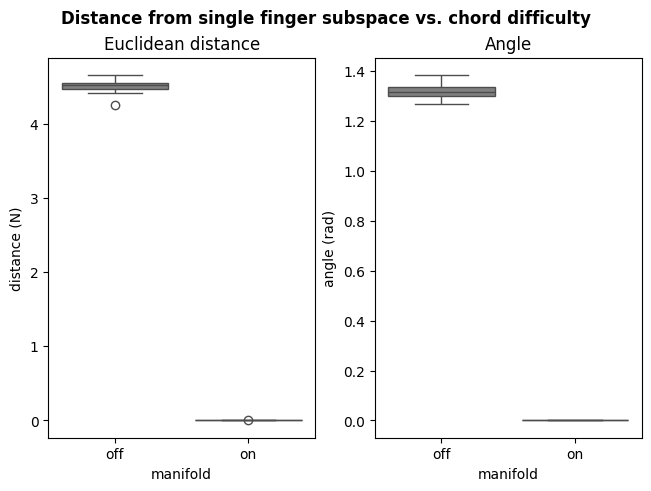

In [ ]:
sim_g = sim.groupby(['sn', 'manifold']).mean(numeric_only=True)

fig, axs = plt.subplots(1, 2, constrained_layout=True)

ax = axs[0]
sb.boxplot(data=sim_g, ax=ax, x='manifold', y='dist', color='grey', )
ax.set_title('Euclidean distance')
ax.set_ylabel('distance (N)')

ax = axs[1]
sb.boxplot(data=sim_g, ax=ax, x='manifold', y='theta',  color='grey',)
ax.set_title('Angle')
ax.set_ylabel('angle (rad)')

fig.suptitle('Distance from single finger subspace vs. chord difficulty', fontweight='bold')

plt.show()
